# Clasificación de Vinos con SVM

## Objetivo

En esta práctica, entrenarás un **clasificador SVM** utilizando el conjunto de datos **Wine Dataset** de sklearn.datasets. Los datos provienen de un análisis químico de vinos cultivados en la misma región de Italia, pero derivados de **tres variedades diferentes**.

El objetivo es clasificar el vino según su variedad basándose en sus propiedades químicas.

**Debes entregar el resultado final de tu trabajo de la siguiente forma:**
* **Archivo .ipynb** con el cuaderno de Jupyter que contenga todas las instrucciones usadas.
* **Archivo .html** con el código y la salida obtenida en su ejecución (debes exportar en formato HTML).

**Es fundamental que comentes el código, para su correcta legibilidad, así como realizar interpretaciones de las salidas que se obtengan.**

---

## 0. Importar librerías necesarias

In [1]:
# Librerías para manipulación de datos
import numpy as np
import pandas as pd

# Librerías de scikit-learn
import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn import svm

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Para reproducibilidad
np.random.seed(42)

## 1. Análisis exploratorio de datos

Genera un conjunto de datos linealmente separable utilizando  **sklearn.datasets.load_wine()** de `scikit-learn`.
* Carga de los datos
* Imprime los primeros 5 registros de datos
* Imprime en pantalla el nombre de las clases de la variable objetivo.

In [2]:
# Cargamos el dataset de vinos
ds = sklearn.datasets.load_wine()

# Creamos un DataFrame para facilitar la exploración
df = pd.DataFrame(data=ds.data, columns=ds.feature_names)

# Imprimir en pantalla el nombre de las clases de la variable objetivo
print("Nombres de las clases de la variable objetivo:")
print(ds.target_names)

# Cambiamos nombre de las variables del dataset a nombres de variables en español
nombres_variables_espanol = {
    'alcohol': 'alcohol',
    'malic_acid': 'acido_malico',
    'ash': 'ceniza',
    'alcalinity_of_ash': 'alcalinidad_ceniza',
    'magnesium': 'magnesio',
    'total_phenols': 'fenoles_totales',
    'flavanoids': 'flavonoides',
    'nonflavanoid_phenols': 'fenoles_no_flavonoides',
    'proanthocyanins': 'proantocianinas',
    'color_intensity': 'intensidad_color',
    'hue': 'matiz',
    'od280/od315_of_diluted_wines': 'od280_od315_vinos_diluidos',
    'proline': 'prolina'
}
df.rename(columns=nombres_variables_espanol, inplace=True)

# Imprimir nombre de todas las variables del dataset
print("Nombres de todas las variables del dataset:")
print(df.columns.tolist())

Nombres de las clases de la variable objetivo:
['class_0' 'class_1' 'class_2']
Nombres de todas las variables del dataset:
['alcohol', 'acido_malico', 'ceniza', 'alcalinidad_ceniza', 'magnesio', 'fenoles_totales', 'flavonoides', 'fenoles_no_flavonoides', 'proantocianinas', 'intensidad_color', 'matiz', 'od280_od315_vinos_diluidos', 'prolina']


In [3]:
# Estadística descriptivasobre las características
print("Estadísticas descriptivas de las características:")
print(df.describe())

Estadísticas descriptivas de las características:
          alcohol  acido_malico      ceniza  alcalinidad_ceniza    magnesio  \
count  178.000000    178.000000  178.000000          178.000000  178.000000   
mean    13.000618      2.336348    2.366517           19.494944   99.741573   
std      0.811827      1.117146    0.274344            3.339564   14.282484   
min     11.030000      0.740000    1.360000           10.600000   70.000000   
25%     12.362500      1.602500    2.210000           17.200000   88.000000   
50%     13.050000      1.865000    2.360000           19.500000   98.000000   
75%     13.677500      3.082500    2.557500           21.500000  107.000000   
max     14.830000      5.800000    3.230000           30.000000  162.000000   

       fenoles_totales  flavonoides  fenoles_no_flavonoides  proantocianinas  \
count       178.000000   178.000000              178.000000       178.000000   
mean          2.295112     2.029270                0.361854         1.590899  

Distribución de clases (variedades de vino):
1    71
0    59
2    48
Name: count, dtype: int64

Gráfico de barras de la distribución de clases:


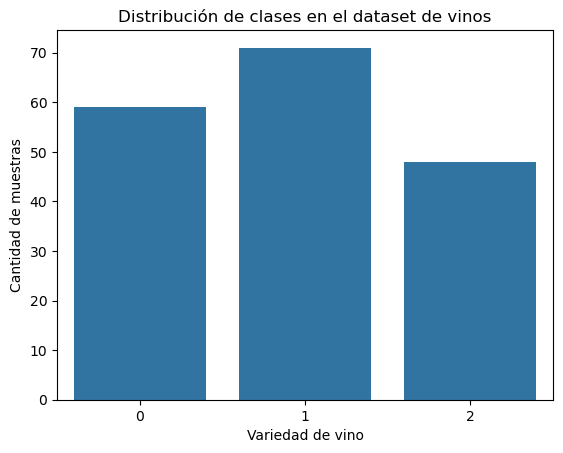

In [4]:
# Análisis de la distribución de clases (variedades de vino)
print("Distribución de clases (variedades de vino):")
print(pd.Series(ds.target).value_counts())

# Visualización de la distribución
print("\nGráfico de barras de la distribución de clases:")
sns.countplot(x=ds.target)
plt.xlabel('Variedad de vino')
plt.ylabel('Cantidad de muestras')
plt.title('Distribución de clases en el dataset de vinos')
plt.show()


In [5]:
# Verificamos si hay valores nulos
print("Número de valores nulos en cada columna:")
print(df.isnull().sum())

Número de valores nulos en cada columna:
alcohol                       0
acido_malico                  0
ceniza                        0
alcalinidad_ceniza            0
magnesio                      0
fenoles_totales               0
flavonoides                   0
fenoles_no_flavonoides        0
proantocianinas               0
intensidad_color              0
matiz                         0
od280_od315_vinos_diluidos    0
prolina                       0
dtype: int64


## 2. Preparación de los Datos

* Genera los conjuntos de entrenamiento y test (20%).
* Realiza el escalado de las características con **StandardScaler**
* Busca y documenta algún otro método de escalado para **SVM**

In [6]:
# Separamos las características (X) de la variable objetivo (y)
X = df.values
y = ds.target

In [7]:
# División en conjuntos de entrenamiento (80%) y prueba (20%)
# stratify=y asegura que la proporción de clases se mantenga en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Escalado de Características

**¿Por qué es importante escalar en SVM?**

Los SVM son algoritmos basados en **distancias**. Características con escalas grandes dominarían el cálculo de distancias, haciendo que el modelo ignore características con valores pequeños pero potencialmente importantes.

**StandardScaler** transforma cada característica para que tenga:
- Media (μ) = 0
- Desviación estándar (σ) = 1

Fórmula: `z = (x - μ) / σ`

In [8]:
# Inicializamos el escalador
scaler = StandardScaler()

# PASO 1: Ajustamos el escalador SOLO con los datos de entrenamiento
# Esto calcula la media y desviación estándar de cada característica en el conjunto de entrenamiento
scaler.fit(X_train)

# PASO 2: Transformamos AMBOS conjuntos usando las estadísticas del conjunto de entrenamiento
# Esto evita "data leakage" (fuga de información del conjunto de prueba)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Comparación visual: antes vs después del escalado
print(
    "Comparación de características antes y después del escalado (primeras 5 características):"
)

# Antes del escalado (primeras 5 características)
print("\nAntes del escalado")
print(X_train[:5])

# Después del escalado (primeras 5 características)
print("\nDespués del escalado")
print(X_train_scaled[:5])

Comparación de características antes y después del escalado (primeras 5 características):

Antes del escalado
[[1.328e+01 1.640e+00 2.840e+00 1.550e+01 1.100e+02 2.600e+00 2.680e+00
  3.400e-01 1.360e+00 4.600e+00 1.090e+00 2.780e+00 8.800e+02]
 [1.373e+01 1.500e+00 2.700e+00 2.250e+01 1.010e+02 3.000e+00 3.250e+00
  2.900e-01 2.380e+00 5.700e+00 1.190e+00 2.710e+00 1.285e+03]
 [1.339e+01 1.770e+00 2.620e+00 1.610e+01 9.300e+01 2.850e+00 2.940e+00
  3.400e-01 1.450e+00 4.800e+00 9.200e-01 3.220e+00 1.195e+03]
 [1.375e+01 1.730e+00 2.410e+00 1.600e+01 8.900e+01 2.600e+00 2.760e+00
  2.900e-01 1.810e+00 5.600e+00 1.150e+00 2.900e+00 1.320e+03]
 [1.332e+01 3.240e+00 2.380e+00 2.150e+01 9.200e+01 1.930e+00 7.600e-01
  4.500e-01 1.250e+00 8.420e+00 5.500e-01 1.620e+00 6.500e+02]]

Después del escalado
[[ 0.38580089 -0.63787118  1.77666817 -1.22453161  0.69643032  0.52686525
   0.73229212 -0.1695489  -0.41578344 -0.16746725  0.62437819  0.2529082
   0.46772474]
 [ 0.94851892 -0.76544542  1.2

## 3. Entrenamiento del Modelo SVM (Baseline)

Comenzamos con un modelo SVM básico usando los parámetros por defecto.

In [10]:
# Creamos el clasificador SVM con parámetros por defecto
# Por defecto: kernel='rbf', C=1.0, gamma='scale'
# decision_function_shape='ovr' significa One-vs-Rest (uno contra todos)
classificador_svm = svm.SVC(decision_function_shape='ovr')

# Entrenamos el modelo
classificador_svm.fit(X_train_scaled, y_train)

# Realizamos predicciones sobre el conjunto de prueba
y_pred = classificador_svm.predict(X_test_scaled)

# Calculamos la precisión (accuracy)
accuracy = sklearn.metrics.accuracy_score(y_test, y_pred)
print(f"Precisión del modelo SVM: {accuracy}")

Precisión del modelo SVM: 0.9722222222222222


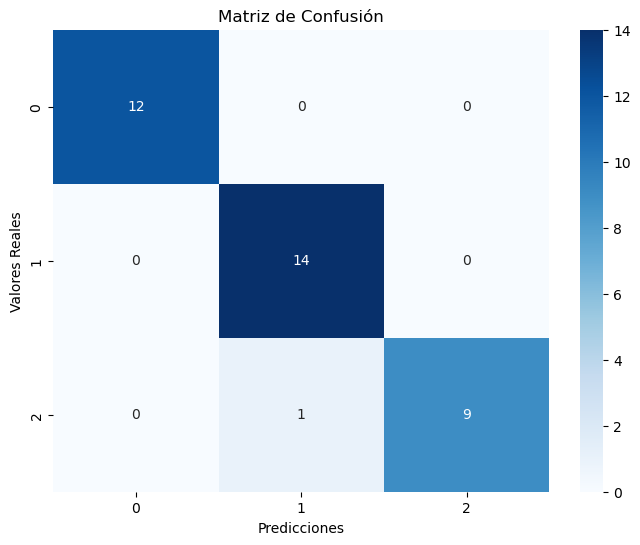

In [11]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualización de la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicciones')
plt.ylabel('Valores Reales')
plt.show()


## 4. Optimización de Hiperparámetros

Utilizaremos **GridSearchCV** para encontrar la mejor combinación de hiperparámetros.

**Hiperparámetros a ajustar:**
- **C**: Parámetro de regularización (trade-off entre margen y error de clasificación)
  - C grande → margen pequeño, menos errores en entrenamiento (riesgo de overfitting)
  - C pequeño → margen grande, más errores tolerados (riesgo de underfitting)
  
- **gamma**: Define qué tan lejos llega la influencia de un punto de entrenamiento
  - gamma grande → influencia cercana (fronteras complejas, riesgo de overfitting)
  - gamma pequeño → influencia lejana (fronteras suaves)
  
- **kernel**: Tipo de función kernel (linear, rbf, poly, sigmoid)

In [12]:
# Definimos el grid de hiperparámetros a probar
hp_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

In [13]:
# Creamos el objeto GridSearchCV
grid_search = GridSearchCV(classificador_svm, param_grid=hp_grid, cv=5)

In [14]:
# Resultados de la búsqueda
grid_search.fit(X_train_scaled, y_train)

print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

# Obtenemos el mejor modelo
mejor_modelo = grid_search.best_estimator_
print("\nMejor modelo encontrado:")
print(mejor_modelo)

Mejores hiperparámetros encontrados:
{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

Mejor modelo encontrado:
SVC(C=0.1, kernel='linear')


In [15]:
# Evaluamos el mejor modelo en el conjunto de prueba
y_pred_mejor = mejor_modelo.predict(X_test_scaled)
accuracy_mejor = sklearn.metrics.accuracy_score(y_test, y_pred_mejor)
print(f"Precisión del mejor modelo SVM: {accuracy_mejor}")

Precisión del mejor modelo SVM: 0.9722222222222222


In [16]:
# Informe de clasificación del modelo optimizado
print("\n=== INFORME DE CLASIFICACIÓN (MODELO OPTIMIZADO) ===")
reporte_clasificacion = classification_report(y_test, y_pred_mejor, target_names=ds.target_names)
print(reporte_clasificacion)

print("\nprecision: De todo lo que el modelo predicjo como esa clase, ¿cuánto es correcto?. Alta precisión indica pocos falsos positivos.")
print("recall: De todo lo que realmente era esa clase, ¿cuánto fue correctamente predicho?. Alta recall indica pocos falsos negativos.")
print("f1-score: Promedio armónico de precisión y recall. Mide el equilibrio entre ambos.")
print("support: Número de instancias reales de esa clase en el conjunto de prueba.")
print("accuracy: Proporción de predicciones correctas sobre el total de instancias en el conjunto de prueba.")
print("macro avg: Promedio de las métricas calculadas para cada clase, sin considerar el soporte de cada clase.")
print("weighted avg: Promedio ponderado de las métricas calculadas para cada clase, considerando el soporte de cada clase.")


=== INFORME DE CLASIFICACIÓN (MODELO OPTIMIZADO) ===
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36


precision: De todo lo que el modelo predicjo como esa clase, ¿cuánto es correcto?. Alta precisión indica pocos falsos positivos.
recall: De todo lo que realmente era esa clase, ¿cuánto fue correctamente predicho?. Alta recall indica pocos falsos negativos.
f1-score: Promedio armónico de precisión y recall. Mide el equilibrio entre ambos.
support: Número de instancias reales de esa clase en el conjunto de prueba.
accuracy: Proporción de predicciones correctas sobre el total de instancias en el conjunto de prueba.
macro avg: Promedio de las métricas calculadas


Matriz de confusión del modelo optimizado:


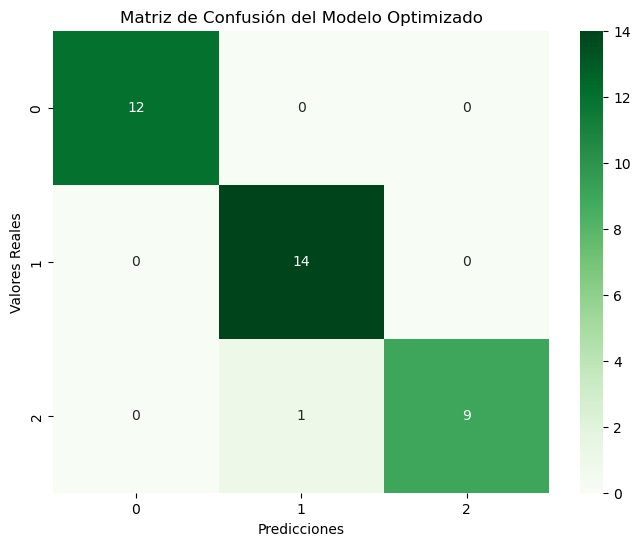

In [17]:
# Matriz de confusión del modelo optimizado
cm_optimizado = confusion_matrix(y_test, y_pred_mejor)

print("\nMatriz de confusión del modelo optimizado:")
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimizado, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión del Modelo Optimizado')
plt.xlabel('Predicciones')
plt.ylabel('Valores Reales')
plt.show()

## 5. Comparación de Modelos con Diferentes Kernels

Entrenamos modelos específicos con cada tipo de kernel para analizar su comportamiento.

In [18]:
# Definimos los kernels a comparar
kernels = ['linear', 'rbf', 'poly']

# Entrenamos un modelo con cada kernel
for kernel in kernels:
    print(f"\nEntrenando modelo SVM con kernel: {kernel}")
    modelo = svm.SVC(kernel=kernel, C=1.0, gamma='scale', decision_function_shape='ovr')
    modelo.fit(X_train_scaled, y_train)
    y_pred_kernel = modelo.predict(X_test_scaled)
    accuracy_kernel = sklearn.metrics.accuracy_score(y_test, y_pred_kernel)
    print(f"Precisión del modelo SVM con kernel '{kernel}': {accuracy_kernel}")



Entrenando modelo SVM con kernel: linear
Precisión del modelo SVM con kernel 'linear': 0.9444444444444444

Entrenando modelo SVM con kernel: rbf
Precisión del modelo SVM con kernel 'rbf': 0.9722222222222222

Entrenando modelo SVM con kernel: poly
Precisión del modelo SVM con kernel 'poly': 0.9444444444444444


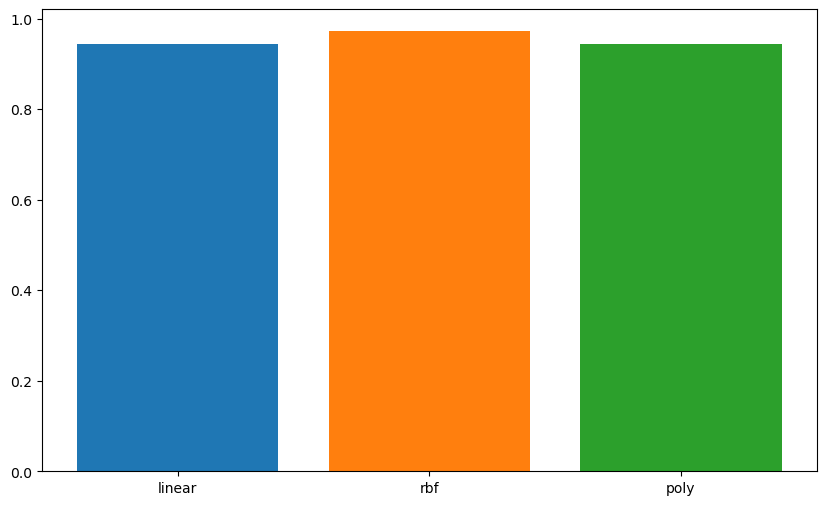

In [19]:
# Comparación visual de los kernels
plt.figure(figsize=(10, 6))
for kernel in kernels:
    modelo = svm.SVC(kernel=kernel, C=1.0, gamma='scale', decision_function_shape='ovr')
    modelo.fit(X_train_scaled, y_train)
    y_pred_kernel = modelo.predict(X_test_scaled)
    accuracy_kernel = sklearn.metrics.accuracy_score(y_test, y_pred_kernel)
    plt.bar(kernel, accuracy_kernel)

## 6. Análisis del Efecto de los Hiperparámetros C y gamma

Precisión del modelo SVM con C=0.1: 0.9722222222222222
Precisión del modelo SVM con C=1: 0.9722222222222222
Precisión del modelo SVM con C=10: 0.9444444444444444
Precisión del modelo SVM con C=100: 0.9444444444444444


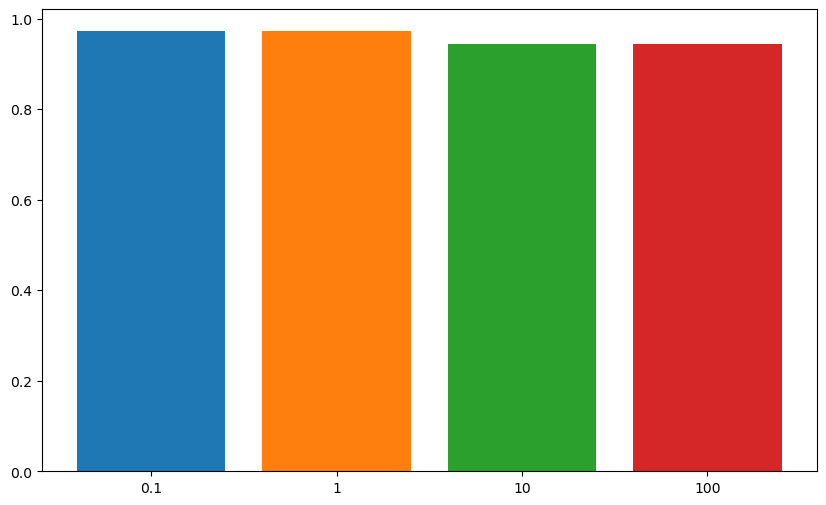

In [20]:
# Analizamos el efecto de C (regularización)
C_values = [0.1, 1, 10, 100]
plt.figure(figsize=(10, 6))
for C in C_values:
    modelo = svm.SVC(kernel='rbf', C=C, gamma='scale', decision_function_shape='ovr')
    modelo.fit(X_train_scaled, y_train)
    y_pred_C = modelo.predict(X_test_scaled)
    accuracy_C = sklearn.metrics.accuracy_score(y_test, y_pred_C)
    print(f"Precisión del modelo SVM con C={C}: {accuracy_C}")
    
for C in C_values:
    modelo = svm.SVC(kernel='rbf', C=C, gamma='scale', decision_function_shape='ovr')
    modelo.fit(X_train_scaled, y_train)
    y_pred_C = modelo.predict(X_test_scaled)
    accuracy_C = sklearn.metrics.accuracy_score(y_test, y_pred_C)
    plt.bar(str(C), accuracy_C)

Precisión del modelo SVM con gamma=scale: 0.9722222222222222
Precisión del modelo SVM con gamma=auto: 0.9722222222222222
Precisión del modelo SVM con gamma=0.001: 0.8611111111111112
Precisión del modelo SVM con gamma=0.01: 1.0
Precisión del modelo SVM con gamma=0.1: 0.9722222222222222
Precisión del modelo SVM con gamma=1: 0.5555555555555556


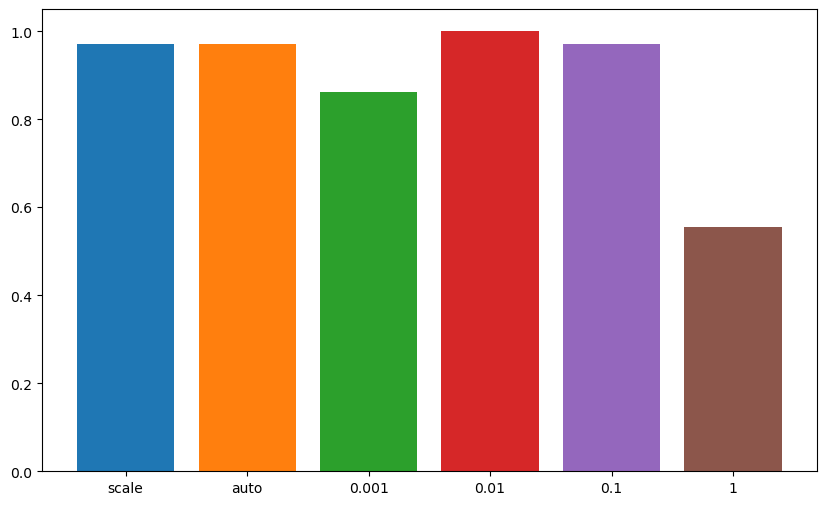

In [21]:
# Analizamos el efecto de gamma
gamma_values = ['scale', 'auto', 0.001, 0.01, 0.1, 1]
plt.figure(figsize=(10, 6))
for gamma in gamma_values:
    modelo = svm.SVC(kernel='rbf', C=1.0, gamma=gamma, decision_function_shape='ovr')
    modelo.fit(X_train_scaled, y_train)
    y_pred_gamma = modelo.predict(X_test_scaled)
    accuracy_gamma = sklearn.metrics.accuracy_score(y_test, y_pred_gamma)
    print(f"Precisión del modelo SVM con gamma={gamma}: {accuracy_gamma}")
    
for gamma in gamma_values:
    modelo = svm.SVC(kernel='rbf', C=1.0, gamma=gamma, decision_function_shape='ovr')
    modelo.fit(X_train_scaled, y_train)
    y_pred_gamma = modelo.predict(X_test_scaled)
    accuracy_gamma = sklearn.metrics.accuracy_score(y_test, y_pred_gamma)
    plt.bar(str(gamma), accuracy_gamma)


## 7. Resumen y Conclusiones

Análisis de los resultados:
- El kernel `rbf` parece ser la mejor opción por su capacidad para manejar relaciones no lineales al analizarlo de forma individual. Sin embargo, la diferencia con el kernel `linear` no es muy grande.
- El parámetro `C`, en este caso, con el valor de `C=1.0` proporcionó un buen equilibrio.
- Para el parámetro `gamma` se observó que el valor `gamma='scale'` proporcionó el mejor desempeño.
- En general, tanto el modelo sin optimización como el modelo optimizado mostraron resultados similares, lo que sugiere que los hiperparámetros por defecto ya eran adecuados para este dataset. Sin embargo, la optimización permitió confirmar que no había mejoras significativas al cambiar los hiperparámetros.

## 8. Respuestas a las Preguntas de Reflexión

### 1. ¿Cuál fue la precisión final del modelo en el conjunto de prueba?

Para ambos modelos (el primero y el optimizado) la presición fue de 0.97.

---

### 2. ¿Hubo diferencias significativas en la clasificación de las tres clases?

No hubibierons diferencias mayores entre las tres clases.

---

### 3. ¿Cómo afectaron C y gamma al rendimiento del modelo?

Con ambos parámetros se obtuvieron resultados similares al modelo no optimizado.

---

### 4. ¿Podrías mejorar la clasificación probando otro kernel (linear, rbf, poly)?

Probablemente no, `linear` y `rbf` dieron resultados muy similares, con `poly` ligeramente peor.


### 9. Conclusiones Finales y Aprendizajes Clave

### Conclusiones finales:

Parece ser que en este dataset, los hiperparámetros por defecto ya nos ayudan a obtener el mejor resultado posible, pues se obtiene el mismo nivel de precisión tanto con el modelo sin optimizar como el optimizado. Esto puede sugerir que el dataset no contiene suficientes muestras y que haya algun ligero sobreajuste.

### Posibles Mejoras:



### Aplicaciones en el Mundo Real:
